# Transfer Success Evaluation

Rule-based framework anchored to destination-adjusted player projections (`player_projections.value_per_100`). No separate ML model â€” success is defined as meeting or exceeding the projection baseline.

| Step | What it does |
|---|---|
| **1. Data Load** | Joins `transfers` â†’ `player_projections` â†’ `player_archetypes` â†’ `team_system_profiles` â†’ `hoop_explorer_player_stats` |
| **2. Success Label** | `actual_value_per_100 >= projected_value_per_100` (primary); `post_per >= pre_per` fallback |
| **3. Drift Metrics** | `minutes_drift`, `usage_drift` = actual minus projected |
| **4. Player Clusters** | Pulled directly from `player_archetypes` |
| **5. Team Clusters** | Pulled directly from `team_system_profiles.system_label` (7 offense Ã— 5 defense, combined) |
| **6. Success Probability** | Empirical Bayes shrinkage over **Player Cluster Ã— Team Cluster** cells, trained on an expanding window of prior seasons only (no in-sample leakage) |
| **7. Similar Transfers + Explanation** | No categorical risk flag â€” named historical comps from the same cell (real player, real outcome) plus `success_probability`/`success_tier` are woven into a plain-language UI string |


In [1]:
# Cell 0 â€” Imports + Config
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# --- Config ---
CURRENT_SEASON = 2026   # season we're projecting into
SHRINKAGE_K    = 15     # Empirical Bayes shrinkage constant (K pseudo-observations from cluster prior)
CELL_MIN_N     = 5      # n below which shrinkage is meaningfully active
DECAY_LAMBDA   = 0.9    # Time-decay per season-of-age (<=1.0); matches the production aggregation job

# Destination-mode player_projections rows for historical seasons are written by the
# validation-only backfill in Section 0 below (NOT the production destination_projection
# pipeline â€” see that section's warning). Pinned to this model_version so TRANSFER_SQL's
# join is unambiguous even if real production data for these same historical seasons
# ever gets written later under a different model_version.
DESTINATION_BACKTEST_MODEL_VERSION = "destination-backtest-v1"
# DEV/NOTEBOOK ONLY — do not compare Section 7 Brier scores to MLflow @champion.
# Production backtest + promotion use player-destination-proj-v1 via scripts/run_transfer_success.py.
PRODUCTION_PROJECTION_MODEL_VERSION = "player-destination-proj-v1"


## 0. Historical Backfill for Validation Only â€” NOT Production Code

> **Callout (Block 5):** `destination-backtest-v1` rows written here are **dev/notebook only**.
> The official MLflow `@champion` baseline and `scripts/run_transfer_success.py` use
> `player-destination-proj-v1`. Section 7 metrics on this notebook are a research reference —
> re-run against production projections before comparing to MLflow Brier.

**This section does not run in production and must never be used as a substitute for it.** The live app always uses `scripts/run_playing_time.py` and `scripts/run_destination_projection.py` â€” the real, production-scoring pipelines that compute projections for every eligible player x every D1 school.

To validate *this* notebook's methodology against real historical outcomes, the cells below:
- Reuse the **real, unmodified trained-model math** from `playing_time.py` / `destination_projection.py` (imported directly, never reimplemented)
- Patch one known SQL join in `destination_projection.py`'s training query **in-memory, for this notebook session only**, never touching the source files on disk (see that cell's own comment for the specific fix)
- Score **only** the exact historical `(player, destination school, season)` triples that already
  happened (per `transfers`), not the full all-D1 candidate pool the production scripts compute.
  The full pool genuinely exists in the DB and *could* be scored the same way production does for
  the live cycle â€” we only have a real outcome to validate against
  for players who actually transferred, so scoring every non-transferring player Ã— every school for
  every historical season would be a large amount of extra compute. Confirmed this
  narrowing doesn't change any result
- Write results to `player_projections` under a distinguishable `model_version` (`DESTINATION_BACKTEST_MODEL_VERSION`), so they can never be confused with real production rows and are trivially removable


In [2]:
# Cell 0.1 â€” Backfill setup: connect, patch the one still-unfixed SQL bug, load target triples
import portalpoint.modeling.playing_time as pt
import portalpoint.modeling.destination_projection as dp
from portalpoint.modeling.io import get_sync_engine
from sqlalchemy import text as sql_text

backfill_engine = get_sync_engine()

# --- hoop_explorer_player_stats missing-DISTINCT-ON bug (see bug report above): fixed
# upstream in playing_time.py (TRAINING_SQL/INFERENCE_SQL now dedupe via a `hep_dedup`
# CTE â€” confirmed after pulling in main). destination_projection.py's _TRANSFER_TRAINING_SQL
# has the identical join, unguarded, and was NOT touched by that fix (same "fixed in one
# file, sibling left exposed" pattern as the statement_timeout gap noted in the PR review) â€”
# still patched here, in-memory, for this notebook session only.

_DP_TRAIN_BUG = (
    "dest_labels AS (\n"
    "    -- No season filter here â€” JOIN condition restricts to dest_season (= portal year + 1)\n"
    "    SELECT player_id, season, off_adj_rapm, def_adj_rapm, adj_rapm_margin\n"
    "    FROM hoop_explorer_player_stats\n"
    "),"
)
_DP_TRAIN_FIX = (
    "dest_labels AS (\n"
    "    -- No season filter here â€” JOIN condition restricts to dest_season (= portal year + 1).\n"
    "    -- DISTINCT ON added (validation-only patch, see bug report above).\n"
    "    SELECT DISTINCT ON (player_id, season) player_id, season, off_adj_rapm, def_adj_rapm, adj_rapm_margin\n"
    "    FROM hoop_explorer_player_stats\n"
    "    ORDER BY player_id, season, id DESC\n"
    "),"
)
assert _DP_TRAIN_BUG in dp._TRANSFER_TRAINING_SQL, "destination_projection._TRANSFER_TRAINING_SQL text changed upstream â€” update this patch"
dp._TRANSFER_TRAINING_SQL = dp._TRANSFER_TRAINING_SQL.replace(_DP_TRAIN_BUG, _DP_TRAIN_FIX)

print("SQL patch applied (in-memory only, this session) â€” destination_projection.py's dest_labels CTE only; playing_time.py's equivalent is fixed upstream now.")

# --- Target triples: exactly the historical (player, destination school, dest season) ---
# combos that TRANSFER_SQL below will actually try to join against â€” same "completed
# transfer" signal (a real destination-season HoopExplorer row exists).
_TARGET_TRIPLES_SQL = """
SELECT DISTINCT
    t.player_id,
    t.to_school_id AS school_id,
    t.season + 1   AS dest_season,
    t.season       AS source_season
FROM transfers t
JOIN hoop_explorer_player_stats he
    ON he.player_id = t.player_id AND he.season = t.season + 1
WHERE t.to_school_id IS NOT NULL
"""
target_triples = pd.read_sql(_TARGET_TRIPLES_SQL, backfill_engine)
print(f"Target triples to backfill: {len(target_triples):,} across dest_seasons {sorted(target_triples['dest_season'].unique().tolist())}")


SQL patch applied (in-memory only, this session) â€” destination_projection.py's dest_labels CTE only; playing_time.py's equivalent is fixed upstream now.
Target triples to backfill: 2,450 across dest_seasons [2022, 2023, 2024, 2025, 2026]


In [3]:
# Cell 0.2 â€” Per-season backfill: train + score narrowly, mirroring the real orchestration
DEST_SEASONS = sorted(target_triples["dest_season"].unique().tolist())
PT_COLS = [
    "player_id", "school_id", "season", "expected_minutes", "expected_minutes_share",
    "minutes_ci_lower", "minutes_ci_upper", "expected_usage", "usage_role",
    "usage_role_confidence", "displaced_minutes", "data_quality_flags", "role_fit",
]

all_records = []
backfill_summary = []

for dest_season in DEST_SEASONS:
    source_season = dest_season - 1
    dp_train_seasons = [s for s in DEST_SEASONS if s < dest_season]
    if not dp_train_seasons:
        print(f"dest_season={dest_season}: skipped â€” no earlier destination-season outcomes to train the delta model on (leakage guard)")
        backfill_summary.append((dest_season, 0, "skipped_no_training_history"))
        continue

    season_triples = target_triples[target_triples["dest_season"] == dest_season]
    school_ids_season = season_triples["school_id"].unique().tolist()

    # --- Playing Time: train on an expanding window up to source_season, score our narrow set ---
    pt_train_seasons = list(range(min(DEST_SEASONS) - 1, source_season + 1))
    pt_train_df = pt.build_training_examples(backfill_engine, seasons=pt_train_seasons)
    pt_models = pt.fit_minutes_usage_models(pt_train_df)

    # Production (run_playing_time.py) materializes INFERENCE_SQL's staging tables once per
    # target season before calling build_inference_pairs() â€” required, not optional caching.
    pt.materialize_inference_staging(
        backfill_engine, target_season=dest_season, source_season=source_season,
        roster_season=source_season,
    )
    pt_frame = pt.build_inference_pairs(
        backfill_engine, season=dest_season, school_ids=school_ids_season,
        source_season=source_season, roster_season=source_season,
        fit_context_season=source_season, team_context_season=source_season,
    )
    pt_frame = pt_frame.merge(
        season_triples[["player_id", "school_id"]].drop_duplicates(),
        on=["player_id", "school_id"], how="inner",
    )
    if pt_frame.empty:
        print(f"dest_season={dest_season}: skipped â€” no scoreable playing-time rows after narrowing (no fit-score candidacy for this pair)")
        backfill_summary.append((dest_season, 0, "skipped_empty_pt_frame"))
        continue

    scored = pt.predict_minutes_usage(pt_models, pt_frame)
    scored = pt.compress_usage_to_roster_budget(scored)
    usage_roles, usage_role_confidences = pt.derive_usage_roles(scored)
    scored["usage_role"] = usage_roles
    scored["usage_role_confidence"] = usage_role_confidences
    scored["role_fit"] = pt.compute_role_fit_scores(scored)
    scored["displaced_minutes"] = pt.allocate_displaced_minutes_batch(scored)
    scored["data_quality_flags"] = pt.data_quality_flags_batch(scored)
    pt_df_season = scored[PT_COLS].copy()

    # --- Destination Projection: mirror run_destination_projection()'s real steps 2-13 ---
    candidate_ids = pt_df_season["player_id"].unique().tolist()
    neutral_df = dp.load_neutral_projections(backfill_engine, candidate_ids, dest_season)
    team_context_df = dp.load_destination_team_context(backfill_engine, source_season)
    fit_context_df = dp.load_pairwise_fit_context(backfill_engine, candidate_ids, source_season)
    roster_df = dp.load_roster_state_features(backfill_engine, source_season)
    source_stats_df = dp.load_source_player_stats(backfill_engine, candidate_ids, source_season)

    training_df = dp.load_historical_transfer_outcomes(backfill_engine, dp_train_seasons)
    training_df = dp.build_destination_training_examples(training_df)

    tier_mean_mat, tier_std_mat = dp.build_competition_tier_matrix(training_df)
    if not training_df.empty:
        training_df = training_df.copy()
        training_df["competition_level_delta"] = dp.compute_competition_level_delta(
            training_df, tier_mean_mat, tier_std_mat
        )
        training_df["role_usage_target"] = training_df["value_delta"] - training_df["competition_level_delta"]
    role_model, role_scaler, role_feature_names, role_residual_std = dp.fit_role_usage_model(training_df)
    usage_coef = dp.estimate_usage_value_coef(neutral_df, source_stats_df)

    frame = dp.build_destination_inference_frame(
        neutral_df=neutral_df, pt_df=pt_df_season, team_context_df=team_context_df,
        fit_context_df=fit_context_df, roster_df=roster_df, source_stats_df=source_stats_df,
        target_season=dest_season, source_season=source_season,
    )
    if frame.empty:
        print(f"dest_season={dest_season}: skipped â€” empty inference frame (neutral projection or PT coverage gap)")
        backfill_summary.append((dest_season, 0, "skipped_empty_inference_frame"))
        continue

    frame["role_usage_delta"] = dp.compute_role_usage_delta(
        frame, role_model, role_scaler, role_feature_names, linear_coef=usage_coef
    )
    frame["style_skill_fit_delta"] = dp.compute_style_skill_fit_delta(frame)
    frame["roster_context_delta"] = dp.compute_roster_context_delta(frame)
    frame["competition_level_delta"] = dp.compute_competition_level_delta(frame, tier_mean_mat, tier_std_mat)
    frame = dp.apply_delta_caps(frame)
    frame = dp.translate_neutral_to_destination_value(frame)

    ci_scale = 1.0
    if not training_df.empty and "dest_total_rapm" in training_df.columns:
        train_pred = training_df[["dest_total_rapm", "neutral_value"]].copy()
        train_pred["destination_value_per_100"] = train_pred["neutral_value"]
        train_pred["value_ci_lower"] = train_pred["neutral_value"] - 2.0
        train_pred["value_ci_upper"] = train_pred["neutral_value"] + 2.0
        ci_scale = dp.calibrate_ci_scale(train_pred, actual_col="dest_total_rapm")

    frame = dp.propagate_destination_uncertainty(frame, role_residual_std, ci_scale)
    frame = dp.translate_rates_to_destination_stats(frame, team_context_df)
    explanation = dp.build_explanation_payload(frame, source_season, dest_season)

    records = dp.build_destination_projection_records(frame, explanation, source_season, dest_season)
    # Swap the hardcoded production model_version (index 15) for our distinguishable backtest one
    records = [t[:15] + (DESTINATION_BACKTEST_MODEL_VERSION,) + t[16:] for t in records]
    all_records.extend(records)

    print(f"dest_season={dest_season}: {len(records)} destination-backtest rows computed "
          f"(targeted {len(season_triples)} known triples, trained on dest_seasons {dp_train_seasons})")
    backfill_summary.append((dest_season, len(records), "ok"))

print(f"\nTotal destination-backtest rows computed across all seasons: {len(all_records):,}")


dest_season=2022: skipped â€” no earlier destination-season outcomes to train the delta model on (leakage guard)
dest_season=2023: 388 destination-backtest rows computed (targeted 397 known triples, trained on dest_seasons [2022])
dest_season=2024: 450 destination-backtest rows computed (targeted 469 known triples, trained on dest_seasons [2022, 2023])
dest_season=2025: 607 destination-backtest rows computed (targeted 624 known triples, trained on dest_seasons [2022, 2023, 2024])
dest_season=2026: 642 destination-backtest rows computed (targeted 663 known triples, trained on dest_seasons [2022, 2023, 2024, 2025])

Total destination-backtest rows computed across all seasons: 2,087


In [4]:
# Cell 0.3 â€” Write backfilled rows (idempotent: clears our own prior backtest rows first)
with backfill_engine.connect() as _conn:
    _deleted = _conn.execute(
        sql_text("DELETE FROM player_projections WHERE projection_mode = 'destination' AND model_version = :mv"),
        {"mv": DESTINATION_BACKTEST_MODEL_VERSION},
    )
    _conn.commit()
    print(f"Cleared {_deleted.rowcount:,} prior destination-backtest rows (model_version={DESTINATION_BACKTEST_MODEL_VERSION!r})")

n_written = dp.upsert_destination_projections(backfill_engine, all_records)
print(f"Wrote {n_written:,} destination-backtest rows to player_projections.")

display(pd.DataFrame(backfill_summary, columns=["dest_season", "rows_written", "status"]))


Cleared 2,087 prior destination-backtest rows (model_version='destination-backtest-v1')
Wrote 2,087 destination-backtest rows to player_projections.


,dest_season,rows_written,status
0,2022,0,skipped_no_training_history
1,2023,388,ok
2,2024,450,ok
3,2025,607,ok
4,2026,642,ok


## 1. Data Loading

Single SQL query joins five tables. Key join: `team_system_profiles` on `(to_school_id, season)` supplies the **DB-native program style**. Team style is a two-layer clustering (7 offense clusters Ã— 5 defense clusters); `system_label` is the combined offense+defense string and is what we use as the team-side clustering key. `cluster_id` (the offense cluster, kept only for backward compatibility) is intentionally not used here since it drops defensive/system identity from the success cells.

**Season semantics** â€” `transfers.season` is the player's **departure** season (the same season as `pre_per`/`pre_minutes_per_game`; confirmed against the `247sports` ingestion ETL, not the arrival season). That means the destination-season outcome â€” the projection we're grading against and the actual post-transfer performance â€” lives at `season + 1`:

| Join | Season used | Why |
|---|---|---|
| `player_archetypes pa` | `t.season` | Archetype as of the departure season itself (`t.season` already *is* the pre-transfer season â€” not `t.season - 1`) |
| `player_projections pp` | `t.season + 1` | Destination-season projection â€” the season actually played at `to_school_id` |
| `hoop_explorer_player_stats he` | `t.season + 1` | Actual post-transfer performance, same destination season as the projection |
| `team_system_profiles tsp` | `t.season` (**not** `+1`) | The destination team's style is only known once real season data exists to cluster on. At real prediction time (before the transfer's destination season is played), `t.season + 1`'s style doesn't exist yet â€” using it here would leak future data that a live system could never have. We deliberately use the most recently *observed* system (`t.season`) as the fit signal, since that's what production can actually see. |
| `player_season_stats dest_pss` | `t.season + 1` | **Not the same thing as `transfers.post_minutes_per_game`/`post_usage_rate`** â€” those columns are a schema placeholder no ingestion script ever populates (see `models.py`'s own comment: "filled after season completes â€” training labels for Model 5" â€” this notebook is that Model 5). `post_minutes_per_game`/`post_usage_rate` below are derived here from real destination-season `player_season_stats` instead. |

| Source column | Maps to | Notes |
|---|---|---|
| `team_system_profiles.system_label` | `team_cluster_label` | Combined offense+defense style string (7 Ã— 5 = 35 combinations) â€” primary team-side clustering key |
| `team_system_profiles.offense_cluster_id` | `team_offense_cluster_id` | Optional sub-dimension (0â€“6, 7 offense clusters) |
| `team_system_profiles.defense_cluster_id` | `team_defense_cluster_id` | Optional sub-dimension (0â€“4, 5 defense clusters) |
| `player_archetypes.archetype_id` | `player_cluster` | 0â€“8, the player's departure season (9 archetypes) |
| `hoop_explorer_player_stats.adj_rapm_margin` | `actual_value_per_100` | `off_adj_rapm - def_adj_rapm` for the destination season â€” same RAPM lineage `value_per_100` is trained against. (Not `adj_rapm_prod_margin`, a playing-time-weighted variant only used elsewhere as a robustness check, correlation â‰ˆ0.4â€“0.6, not an identity.) |


In [2]:
# Cell 1 â€” DB connect + load all transfer evaluation data
TRANSFER_SQL = f"""
SELECT
    t.id                              AS transfer_id,
    t.player_id,
    p.full_name                       AS player_name,
    t.from_school_id,
    t.to_school_id,
    t.season,
    t.transfer_type,
    -- Pre-transfer snapshot
    t.pre_per,
    t.pre_minutes_per_game,
    t.pre_usage_rate,
    -- Post-transfer actuals.
    -- transfers.post_per / post_minutes_per_game / post_usage_rate are schema
    -- placeholders (models.py: "filled after season completes â€” training labels for
    -- Model 5" â€” this notebook IS Model 5) that NO ingestion script ever populates;
    -- confirmed empirically (all NULL) and by source search (zero writers besides the
    -- schema definition). t.post_per is kept as-is (always NULL â€” the success label
    -- already uses he.adj_rapm_margin below, not post_per). post_minutes_per_game and
    -- post_usage_rate below are DERIVED here from player_season_stats at the destination
    -- season instead of read from transfers â€” NOT the same column as t.post_minutes_per_game.
    -- Minutes formula matches minutes.py::resolved_minutes_per_game (min_pct/100 * 40).
    t.post_per,
    (dest_pss.min_pct / 100.0) * 40.0 AS post_minutes_per_game,
    dest_pss.usage_rate               AS post_usage_rate,
    t.per_change,
    t.minutes_change,
    -- Destination-adjusted projection (our 50th-pct value baseline)
    pp.value_per_100                  AS projected_value_per_100,
    pp.projected_minutes,
    pp.projected_usage,
    pp.value_ci_lower,
    pp.value_ci_upper,
    -- Player archetype for the pre-transfer (departure) season
    pa.archetype_id                   AS player_cluster,
    pa.archetype_label                AS player_cluster_label,
    -- DB-native program style from team_system_profiles (Model 2 output)
    -- Combined offense+defense style string â€” unique per (school_id, season)
    tsp.system_label                  AS team_cluster_label,
    tsp.offense_cluster_id            AS team_offense_cluster_id,
    tsp.defense_cluster_id            AS team_defense_cluster_id,
    -- HoopExplorer actual RAPM for the destination season (t.season + 1).
    -- adj_rapm_margin = off_adj_rapm - def_adj_rapm, the plain (non-production-weighted)
    -- margin â€” the actual RAPM lineage value_per_100 is trained against (player_projection.py).
    -- NOT adj_rapm_prod_margin: that's a playing-time-weighted variant used elsewhere only
    -- as a robustness check, not the training target â€” comparing it here would bias the label.
    he.adj_rapm_margin                AS actual_value_per_100
FROM transfers t
JOIN players p
    ON  p.id = t.player_id
-- Destination-adjusted projection for this player Ã— school, for the season actually
-- played at the destination (t.season is the departure season, so +1)
LEFT JOIN player_projections pp
    ON  pp.player_id       = t.player_id
    AND pp.school_id       = t.to_school_id
    AND pp.season          = (t.season + 1)
    AND pp.projection_mode = 'destination'
    AND pp.model_version   = '{DESTINATION_BACKTEST_MODEL_VERSION}'
-- Player archetype label as of the departure season itself.
-- t.season beats t.season-1 here: it's the player's most recent completed season (freshest
-- read on current form), and it's never a thin partial season since transfers in this ETL
-- only happen between complete seasons
LEFT JOIN player_archetypes pa
    ON  pa.player_id = t.player_id
    AND pa.season    = t.season
-- DB-native program cluster for the destination team, observed as of the departure
-- season (t.season, NOT t.season + 1). The destination team's t.season+1 style can't
-- exist yet at real decision time â€” it requires that season's real box-score data,
-- which hasn't been played. Using the most recently observed system avoids leaking
-- future data that a live system could never have at prediction time.
LEFT JOIN team_system_profiles tsp
    ON  tsp.school_id = t.to_school_id
    AND tsp.season    = t.season
-- HoopExplorer actual performance for the destination season (t.season + 1) â€”
-- same season as the destination projection, for a like-for-like comparison. Joins on
-- adj_rapm_margin (see column comment above), not adj_rapm_prod_margin.
LEFT JOIN hoop_explorer_player_stats he
    ON  he.player_id = t.player_id
    AND he.season    = (t.season + 1)
-- Real post-transfer minutes/usage, derived from player_season_stats at the destination
-- season (t.season + 1) â€” see post_minutes_per_game/post_usage_rate column comment above.
-- Same source destination_projection.py's own training query (dest_stats CTE) uses,
-- rather than the never-populated transfers.post_* columns.
LEFT JOIN player_season_stats dest_pss
    ON  dest_pss.player_id = t.player_id
    AND dest_pss.school_id = t.to_school_id
    AND dest_pss.season    = (t.season + 1)
-- "Completed transfer" = real destination-season outcome exists. transfers.post_* is
-- never populated by any ingestion script (structural gap, confirmed empirically), so we
-- use he.player_id (the destination-season HoopExplorer match) as the actual completion
-- signal instead â€” matches the pattern destination_projection.py's own training query uses.
WHERE he.player_id IS NOT NULL
ORDER BY t.season, t.player_id
"""

from portalpoint.modeling.io import get_sync_engine
engine = get_sync_engine()
conn   = engine.raw_connection()

df_transfers = pd.read_sql(TRANSFER_SQL, conn)
conn.close()

print(f"Loaded {len(df_transfers):,} completed transfers across {df_transfers['season'].nunique()} seasons")
print(f"  Rows with team_cluster_label:  {df_transfers['team_cluster_label'].notna().sum():,}")
print(f"  Rows with player_cluster:   {df_transfers['player_cluster'].notna().sum():,}")
print(f"  Rows with actual RAPM:      {df_transfers['actual_value_per_100'].notna().sum():,}")
print(f"  Rows with projection:       {df_transfers['projected_value_per_100'].notna().sum():,}")

Loaded 2,665 completed transfers across 5 seasons
  Rows with team_cluster_label:  2,448
  Rows with player_cluster:   2,068
  Rows with actual RAPM:      2,665
  Rows with projection:       2,087


/var/folders/jk/yhh2dpf526g65rw0lbdvql6c0000gn/T/ipykernel_99420/1340590479.py:102: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transfers = pd.read_sql(TRANSFER_SQL, conn)


## 2. Success Label & Drift Metrics

**Success Label** â€” a Boolean flag:
- **Primary**: `actual_value_per_100 >= projected_value_per_100`
  - `actual_value_per_100` = `hoop_explorer_player_stats.adj_rapm_margin` (same RAPM lineage as the projection's `value_per_100` â€” not `adj_rapm_prod_margin`, a differently-derived playing-time-weighted variant)
- **Fallback**: `post_per >= pre_per` when no HoopExplorer row exists for this player-season

**Drift Metrics** â€” raw signed deviations:
- `minutes_drift` = `post_minutes_per_game âˆ’ projected_minutes`
- `usage_drift`   = `post_usage_rate âˆ’ projected_usage`

Negative = player got less than projected; positive = exceeded projection.

In [ ]:
# Cell 3 — Success label + drift
# Logic lives in src/portalpoint/modeling/transfer_success.py (label_transfer_success, compute_drift).
from portalpoint.modeling.transfer_success import label_transfer_success, compute_drift

df = label_transfer_success(df_transfers)
df = compute_drift(df)

print("Label source breakdown:")
print(df["label_source"].value_counts().to_string())
print(f"
Overall success rate: {df['success'].mean():.1%}  (n={df['success'].notna().sum():,} labeled)")
print(f"Unlabeled (missing data): {df['success'].isna().sum():,}")

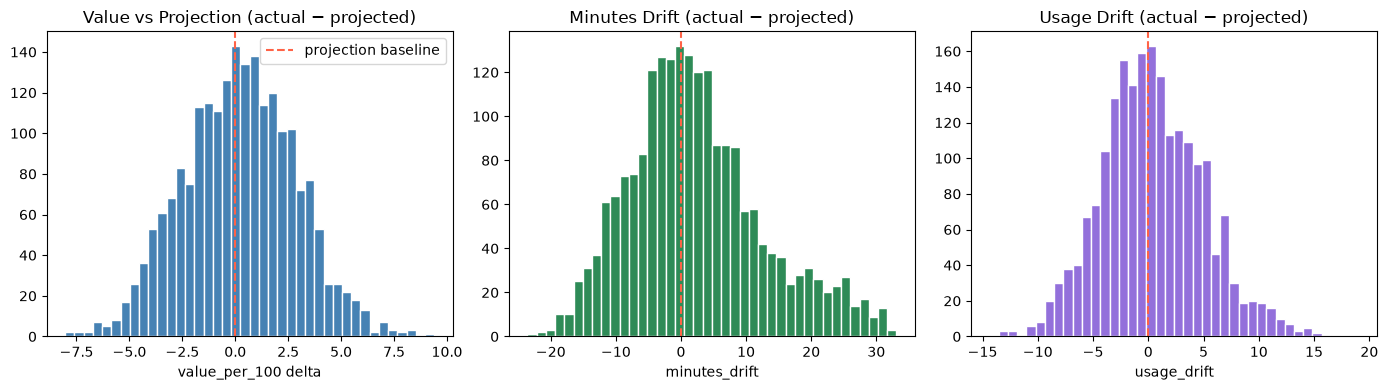


Drift summary stats:


,value_vs_projection,minutes_drift,usage_drift
count,2087.000,2075.000,2075.000
mean,0.194,2.385,0.389
std,2.638,10.416,4.617
min,-8.034,-23.592,-14.360
25%,-1.636,-4.642,-2.704
50%,0.218,1.094,0.113
75%,2.003,8.205,3.426
max,9.398,33.086,19.029


In [4]:
# Cell 4 â€” Drift distribution diagnostics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["value_vs_projection"].dropna(), bins=40, edgecolor="white", color="steelblue")
axes[0].axvline(0, color="tomato", linewidth=1.5, linestyle="--", label="projection baseline")
axes[0].set_title("Value vs Projection (actual âˆ’ projected)")
axes[0].set_xlabel("value_per_100 delta")
axes[0].legend()

axes[1].hist(df["minutes_drift"].dropna(), bins=40, edgecolor="white", color="seagreen")
axes[1].axvline(0, color="tomato", linewidth=1.5, linestyle="--")
axes[1].set_title("Minutes Drift (actual âˆ’ projected)")
axes[1].set_xlabel("minutes_drift")

axes[2].hist(df["usage_drift"].dropna(), bins=40, edgecolor="white", color="mediumpurple")
axes[2].axvline(0, color="tomato", linewidth=1.5, linestyle="--")
axes[2].set_title("Usage Drift (actual âˆ’ projected)")
axes[2].set_xlabel("usage_drift")

plt.tight_layout()
plt.show()

print("\nDrift summary stats:")
display(df[["value_vs_projection", "minutes_drift", "usage_drift"]].describe().round(3))

## 3. Team Cluster Inspection

The program cluster dimension comes directly from `team_system_profiles.system_label` â€” the combined offense (7 clusters) Ã— defense (5 clusters) style string. We use `system_label` rather than `cluster_id` (the offense cluster kept only for backward compatibility) because `cluster_id` alone drops the defensive/system identity from the success cells.

This cell provides a quick EDA of how historical transfers are distributed across team clusters (`system_label`) and what the raw (un-shrunk) success rate looks like per cluster.


In [5]:
# Cell 5 â€” Team cluster coverage EDA
unmatched = df["team_cluster_label"].isna().sum()
print(f"Transfers without a team_system_profiles row: {unmatched:,} ({unmatched/len(df):.1%})")
print("These will receive confidence = global cluster prior (W=0 shrinkage).\n")

team_cluster_summary = (
    df[df["team_cluster_label"].notna()]
    .groupby("team_cluster_label", dropna=False)
    .agg(
        n_transfers=("transfer_id", "count"),
        raw_success_rate=("success", "mean"),
        mean_minutes_drift=("minutes_drift", "mean"),
        mean_usage_drift=("usage_drift", "mean"),
    )
    .reset_index()
    .sort_values("n_transfers", ascending=False)
)

print("Transfers per DB team cluster (team_system_profiles.system_label):")
display(team_cluster_summary.round(3))

# Also show cross-tab of player clusters vs team clusters
print("\nPlayer cluster Ã— Team cluster transfer counts:")
crosstab = (
    df[df["team_cluster_label"].notna() & df["player_cluster"].notna()]
    .groupby(["player_cluster", "team_cluster_label"])
    .size()
    .unstack(fill_value=0)
)
display(crosstab)


Transfers without a team_system_profiles row: 217 (8.1%)
These will receive confidence = global cluster prior (W=0 shrinkage).

Transfers per DB team cluster (team_system_profiles.system_label):


,team_cluster_label,n_transfers,raw_success_rate,mean_minutes_drift,mean_usage_drift
33,Rim Pressure Offense / Rim-Exposure Defense,148,0.630,0.893,-0.094
32,Rim Pressure Offense / Jump-Shot Funnel Defense,136,0.700,-0.442,-0.300
26,Perimeter Creation Offense / Jump-Shot Funnel ...,111,0.620,0.188,-0.104
14,Deliberate Half-Court Offense / Jump-Shot Funn...,109,0.709,-0.089,0.138
35,Rim Pressure Offense / Transition-Vulnerable D...,106,0.429,3.939,1.090
29,Perimeter Creation Offense / Transition-Vulner...,100,0.260,4.156,1.142
12,Deliberate Half-Court Offense / Controlled Hal...,98,0.622,1.323,0.389
9,Balanced Spread Attack / Rim-Exposure Defense,94,0.467,1.968,0.916
27,Perimeter Creation Offense / Rim-Exposure Defense,89,0.538,2.967,0.294
15,Deliberate Half-Court Offense / Rim-Exposure D...,86,0.568,2.449,-0.027



Player cluster Ã— Team cluster transfer counts:


team_cluster_label,3PT Spacing Offense / Controlled Half-Court Defense,3PT Spacing Offense / Defense Unavailable,3PT Spacing Offense / Jump-Shot Funnel Defense,3PT Spacing Offense / Rim-Exposure Defense,3PT Spacing Offense / Scramble-Heavy Set Defense,3PT Spacing Offense / Transition-Vulnerable Defense,Balanced Spread Attack / Controlled Half-Court Defense,Balanced Spread Attack / Defense Unavailable,Balanced Spread Attack / Jump-Shot Funnel Defense,Balanced Spread Attack / Rim-Exposure Defense,Balanced Spread Attack / Scramble-Heavy Set Defense,Balanced Spread Attack / Transition-Vulnerable Defense,Deliberate Half-Court Offense / Controlled Half-Court Defense,Deliberate Half-Court Offense / Defense Unavailable,Deliberate Half-Court Offense / Jump-Shot Funnel Defense,Deliberate Half-Court Offense / Rim-Exposure Defense,Deliberate Half-Court Offense / Scramble-Heavy Set Defense,Deliberate Half-Court Offense / Transition-Vulnerable Defense,Mid-Range Half-Court Offense / Controlled Half-Court Defense,Mid-Range Half-Court Offense / Defense Unavailable,Mid-Range Half-Court Offense / Jump-Shot Funnel Defense,Mid-Range Half-Court Offense / Rim-Exposure Defense,Mid-Range Half-Court Offense / Scramble-Heavy Set Defense,Mid-Range Half-Court Offense / Transition-Vulnerable Defense,Perimeter Creation Offense / Controlled Half-Court Defense,Perimeter Creation Offense / Defense Unavailable,Perimeter Creation Offense / Jump-Shot Funnel Defense,Perimeter Creation Offense / Rim-Exposure Defense,Perimeter Creation Offense / Scramble-Heavy Set Defense,Perimeter Creation Offense / Transition-Vulnerable Defense,Rim Pressure Offense / Controlled Half-Court Defense,Rim Pressure Offense / Defense Unavailable,Rim Pressure Offense / Jump-Shot Funnel Defense,Rim Pressure Offense / Rim-Exposure Defense,Rim Pressure Offense / Scramble-Heavy Set Defense,Rim Pressure Offense / Transition-Vulnerable Defense,Transition Attack / Controlled Half-Court Defense,Transition Attack / Defense Unavailable,Transition Attack / Jump-Shot Funnel Defense,Transition Attack / Rim-Exposure Defense,Transition Attack / Scramble-Heavy Set Defense,Transition Attack / Transition-Vulnerable Defense
player_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0.000,3,0,7,3,1,5,4,0,8,11,4,4,11,0,18,16,5,6,8,2,7,12,3,4,9,0,18,7,8,8,7,1,22,21,6,9,9,0,12,7,2,6
1.000,6,0,3,2,2,1,2,1,5,8,1,3,2,0,12,3,2,1,2,1,5,1,1,8,4,0,6,5,7,6,1,1,6,5,8,8,1,0,0,4,2,2
2.000,2,0,3,2,4,2,6,0,2,2,1,1,10,0,3,4,0,1,2,0,3,3,3,2,4,0,7,2,1,4,2,0,4,4,2,3,2,1,4,4,5,2
3.000,0,0,7,3,1,0,0,0,5,5,3,1,2,0,3,3,0,2,1,1,6,1,4,1,6,0,9,7,3,3,1,0,6,13,3,4,1,0,6,1,0,4
4.000,8,0,18,3,3,3,7,0,12,8,5,4,13,0,17,14,7,3,8,2,13,14,2,6,11,0,14,16,10,12,15,3,31,30,8,16,6,0,12,6,1,11
5.000,11,0,1,2,2,2,7,2,11,7,4,6,7,0,6,2,4,3,8,0,3,1,3,6,4,1,3,10,9,10,3,2,7,9,5,11,3,0,2,4,4,6
6.000,2,1,8,6,5,2,4,0,12,17,8,5,10,0,10,10,12,2,8,0,5,5,3,8,1,1,10,13,6,15,7,4,22,19,7,8,3,0,7,10,1,7
7.000,6,0,9,5,2,6,6,0,9,10,5,4,18,2,14,12,4,3,1,2,4,2,4,9,8,0,11,8,12,10,7,0,13,11,8,11,4,0,6,9,4,6
8.000,1,0,1,3,1,0,5,1,3,5,2,0,6,0,12,6,1,1,3,3,3,3,1,2,7,0,11,1,2,5,3,3,10,10,3,8,3,0,3,3,1,4


## 4. Empirical Bayes Success Probability

We compute a historical success rate for each **`(player_cluster, team_cluster_label)`** cell â€” where both dimensions come directly from the DB (`team_cluster_label` = `system_label`, the combined offense+defense style) â€” then shrink thin cells toward the global rate for that player cluster.

**Expanding window, no leakage**: a transfer in season `S` is only scored using cell/cluster/global rates computed from **completed transfers in seasons strictly before `S`**. Without this, a transfer's own outcome would contribute to the very rate used to score it â€” inflating the Brier score, calibration, and risk-flag precision/recall computed in Section 7. The earliest season in the data has no prior season to train on, so it falls back to an uninformative 0.5 prior (`cell_n = 0`, `shrinkage_w = 0`).

**Time-decay weighting**: to match the production background aggregation job, the training window is **expanding, not rolling** â€” every prior season is kept, not dropped, to maximize sample size. Instead, older transfers are down-weighted by recency:

$$w_i = \lambda^{\,(S - s_i)}$$

where $s_i$ is transfer $i$'s season, $S$ is the season being scored, and $\lambda$ (`DECAY_LAMBDA`, default 0.9, $\lambda \le 1.0$) controls how fast older seasons lose influence. Cell, cluster, and global rates are decay-weighted averages, and the $n$ used in the shrinkage formula below is the **sum of decay weights** (an effective, recency-adjusted sample size) rather than a raw transfer count â€” so a large but stale cohort can contribute less than a smaller, recent one.

**Shrinkage formula**:

$$W = \frac{n}{n + K}$$

$$\text{probability} = W \cdot \text{cell\_rate} + (1 - W) \cdot \text{cluster\_rate}$$

- $n$ = decay-weighted effective sample size in the `(player_cluster, team_cluster_label)` cell, from all prior seasons
- $K = 15$ â€” adding 15 pseudo-observations from the cluster-level prior
- **When $n \gg K$**: probability â‰ˆ cell rate (cell has enough effective historical signal)
- **When $n < 5$**: shrinkage is active, probability pulls toward the safer cluster prior
- **When `team_cluster_label` is NULL** (no `team_system_profiles` row): $W = 0$, probability = cluster prior

The three-level hierarchy is (all rates computed from seasons strictly earlier than the row being scored, decay-weighted by recency):
```
player_cluster Ã— team_cluster_label  (cell, n >= 5: trust cell rate)
    â†“ shrink if n < 5
player_cluster global rate            (cluster prior)
    â†“ if player_cluster also missing
global average                        (overall population prior, prior seasons only)
    â†“ if no prior season exists at all (earliest season in the data)
uninformative 0.5 prior
```



In [ ]:
# Cell 6 — Empirical Bayes probability scoring
# Logic lives in src/portalpoint/modeling/transfer_success.py (compute_success_probability).
# Notebook re-imports so changes to the module take effect without restarting the kernel.
import importlib
import portalpoint.modeling.transfer_success as ts_mod
importlib.reload(ts_mod)

from portalpoint.modeling.transfer_success import compute_success_probability, SHRINKAGE_K, DECAY_LAMBDA

df = compute_success_probability(df, shrinkage_k=SHRINKAGE_K, decay_lambda=DECAY_LAMBDA)

print(f"Shrinkage weight distribution (W = n / (n + {SHRINKAGE_K})), n = decay-weighted effective sample size:")
display(
    df[["cell_n", "shrinkage_w", "cluster_success_rate", "cell_success_rate", "success_probability"]]
    .describe().round(3)
)
print("
Transfers per confidence tier:")
display(df["success_tier"].value_counts().sort_index())

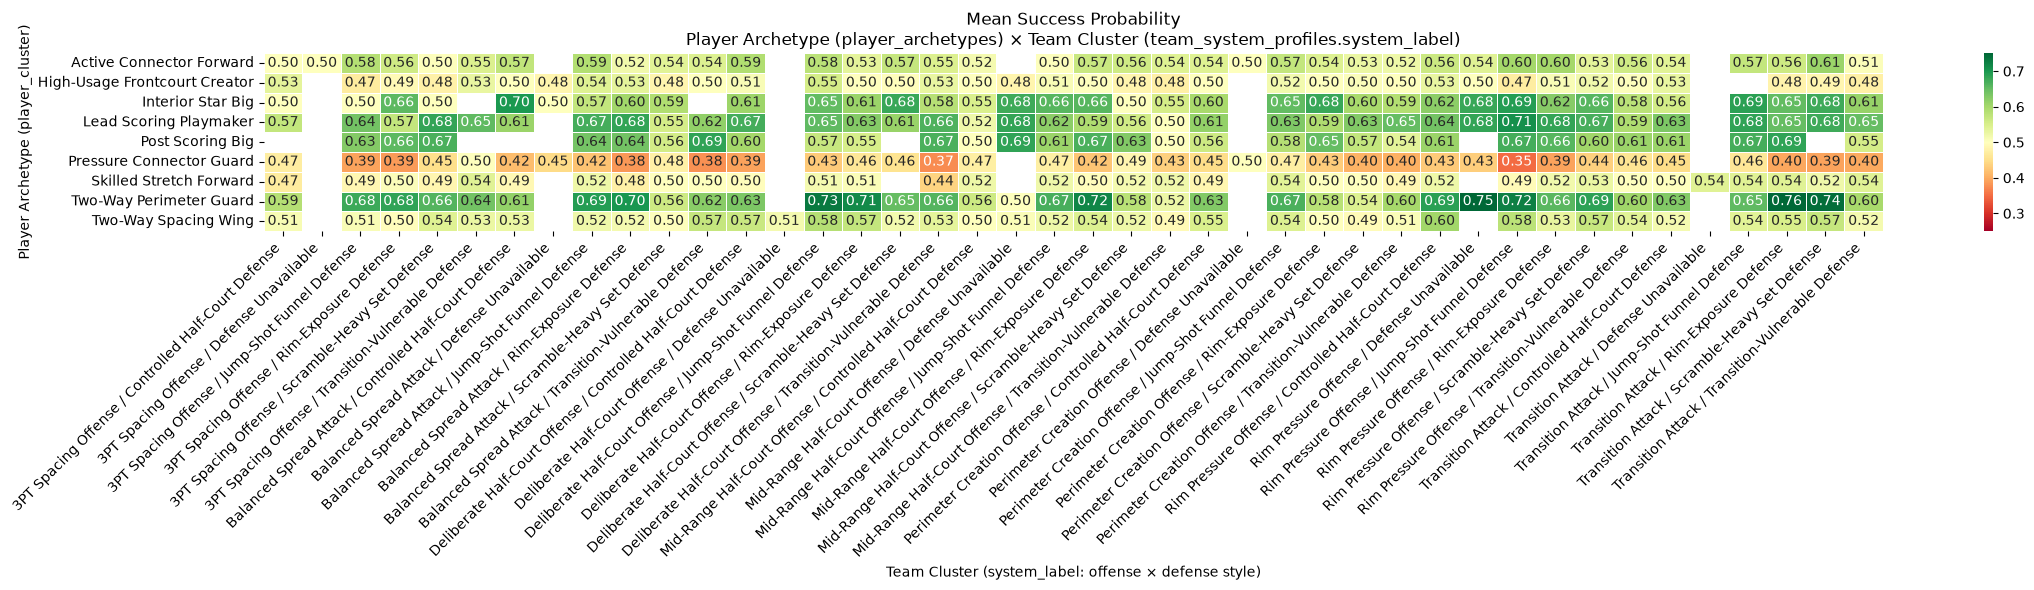

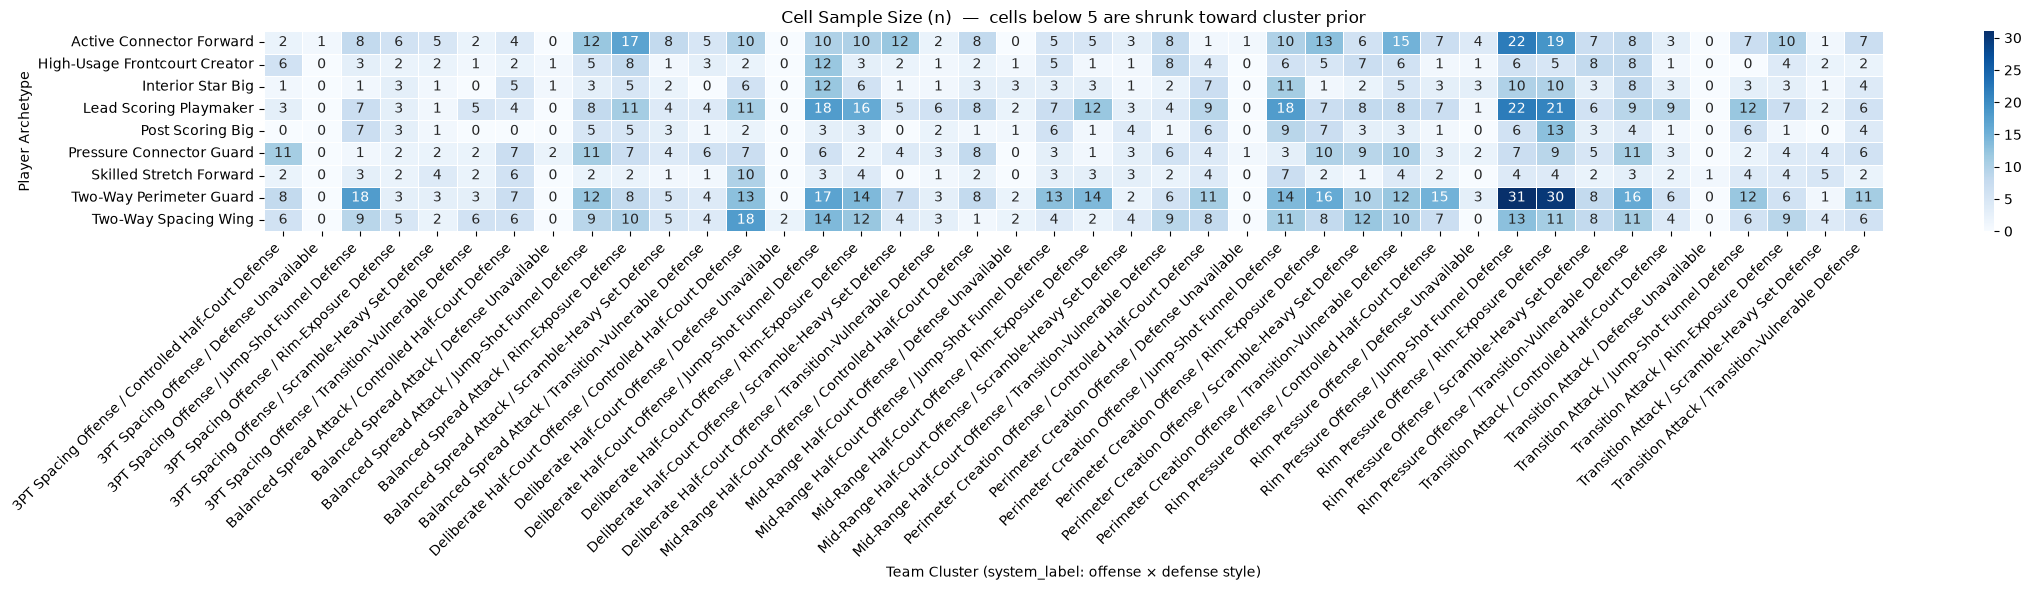

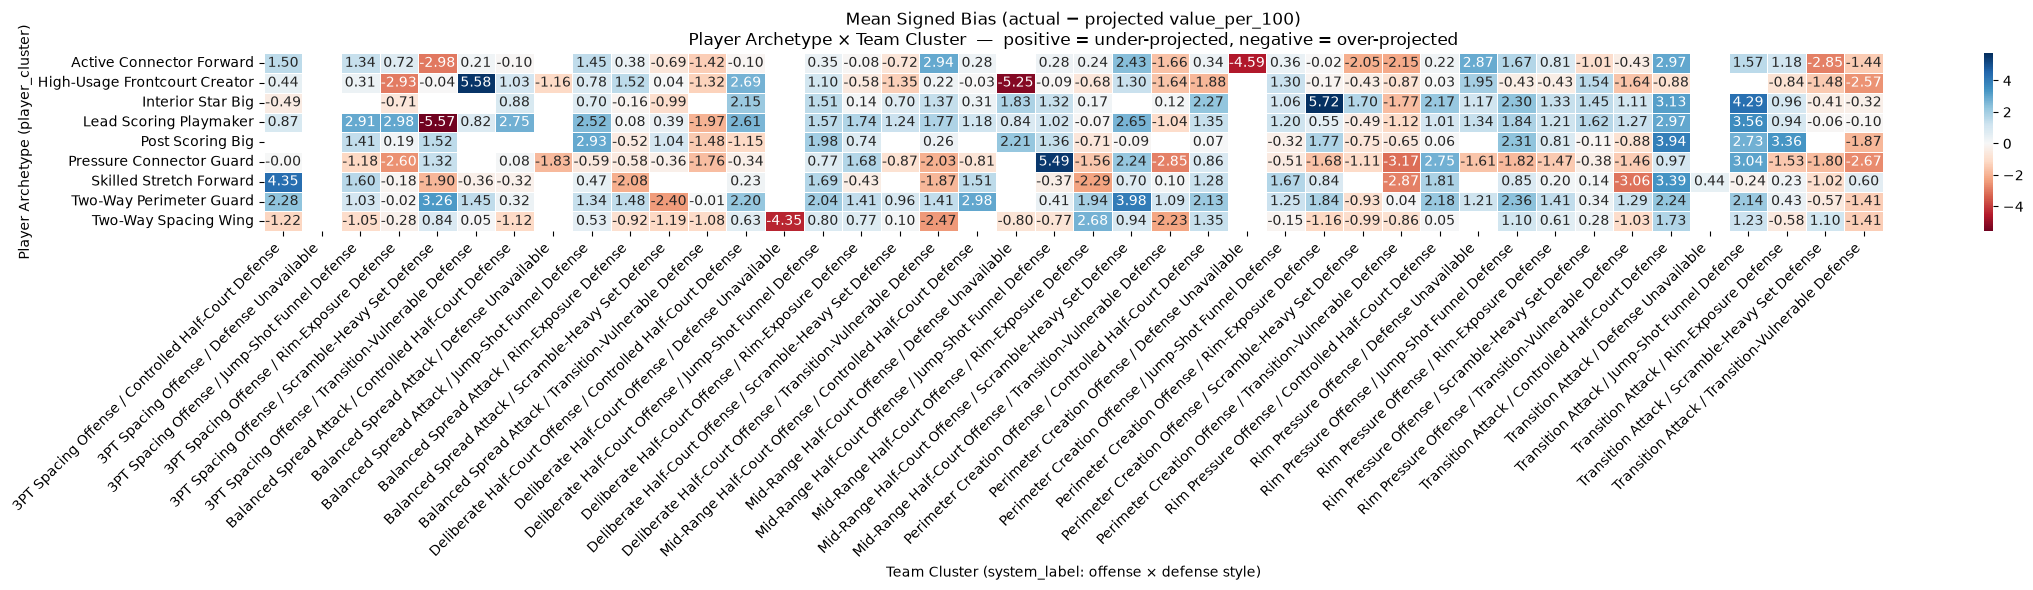

In [7]:
# Cell 7 â€” Probability heatmap: player_cluster Ã— team_cluster_label (both DB-native)
valid = df[df["team_cluster_label"].notna() & df["player_cluster"].notna()].copy()
valid["player_cluster"] = valid["player_cluster"].astype(int)

# Pivot: rows = player archetype, columns = team cluster (system_label: offense + defense combined)
heatmap_data = (
    valid.groupby(["player_cluster_label", "team_cluster_label"])["success_probability"]
    .mean()
    .unstack("team_cluster_label")
)

fig, ax = plt.subplots(figsize=(max(14, 0.55 * heatmap_data.shape[1]), 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0.25, vmax=0.75,
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    "Mean Success Probability\nPlayer Archetype (player_archetypes) Ã— Team Cluster (team_system_profiles.system_label)",
    fontsize=12,
)
ax.set_ylabel("Player Archetype (player_cluster)")
ax.set_xlabel("Team Cluster (system_label: offense Ã— defense style)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Also show raw cell counts to visualize where n < CELL_MIN_N (shrinkage active)
cell_counts = (
    valid.groupby(["player_cluster_label", "team_cluster_label"])
    .size()
    .unstack("team_cluster_label", fill_value=0)
)

fig2, ax2 = plt.subplots(figsize=(max(14, 0.55 * cell_counts.shape[1]), 6))
sns.heatmap(
    cell_counts,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax2,
)
ax2.set_title(
    f"Cell Sample Size (n)  â€”  cells below {CELL_MIN_N} are shrunk toward cluster prior",
    fontsize=12,
)
ax2.set_ylabel("Player Archetype")
ax2.set_xlabel("Team Cluster (system_label: offense Ã— defense style)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Signed bias heatmap: mean (actual âˆ’ projected) value_per_100 per cell â€” same
# player_cluster Ã— team_cluster_label grid as above, but measuring real projection
# accuracy/direction instead of predicted probability. Positive = model under-projected
# (actual outperformed); negative = model over-projected (actual fell short).
bias_data = (
    valid.groupby(["player_cluster_label", "team_cluster_label"])["value_vs_projection"]
    .mean()
    .unstack("team_cluster_label")
)

fig3, ax3 = plt.subplots(figsize=(max(14, 0.55 * bias_data.shape[1]), 6))
sns.heatmap(
    bias_data,
    annot=True, fmt=".2f",
    cmap="RdBu", center=0,
    linewidths=0.5,
    ax=ax3,
)
ax3.set_title(
    "Mean Signed Bias (actual âˆ’ projected value_per_100)\n"
    "Player Archetype Ã— Team Cluster  â€”  positive = under-projected, negative = over-projected",
    fontsize=12,
)
ax3.set_ylabel("Player Archetype (player_cluster)")
ax3.set_xlabel("Team Cluster (system_label: offense Ã— defense style)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Similar Historical Transfers + Explanation

 `cluster_minutes_drift`/`cluster_usage_drift` (a shrinkage-blended
historical average role-change pattern per cell, built the same expanding-window/decay way as
`success_probability`) were tried and dropped from this pipeline. 

**It runs backwards from intuition.** Mean historical role change vs. mean historical
success rate, by archetype:

| Archetype | mean `minutes_drift` | mean `usage_drift` | mean `success_probability` |
|---|---|---|---|
| Two-Way Perimeter Guard | **-2.19** | -0.80 | **0.654** (highest) |
| Pressure Connector Guard | -1.50 | **+0.51** (highest) | **0.424** (lowest) |
| High-Usage Frontcourt Creator | +0.26 | +0.09 | 0.507 |
| Interior Star Big | -1.04 | -1.45 | 0.622 |

Archetypes that historically **lose** the most role (minutes/usage down) have the **highest**
success rates; archetypes that **gain** role have the **lowest**. A working hypothesis, not a
proven mechanism: `success_label` is graded against a projection that already bakes in an
expected role â€” a player who ends up with *less* role than projected but still clears that
(lower) bar is likely an efficient, selectively-used contributor, which a per-100 rate stat
rewards; a player thrust into an unexpectedly *bigger* role may be absorbing tougher minutes
than anticipated, making the (higher) bar harder to clear even with a decent box score.

**Why that means drift doesn't belong in the explanation.** Whatever the mechanism, citing a
number that moves *opposite* to the reader's intuition ("your projected role is shrinking" â‡’
implicitly read as bad news) to explain a probability that's actually *higher* because of that
same shrinkage is confusing. So instead, `success_probability`/`success_tier` stays the 
single primary number, and the explanation is **named historical comps**: real transfers from the same
`(player_cluster Ã— team_cluster_label)` cell, each shown with their actual outcome
(`value_vs_projection` â€” how far actual value came in above/below what was projected). 


In [ ]:
# Cell 8 — Similar historical transfers + explanation text
# Logic lives in src/portalpoint/modeling/transfer_success.py (attach_similar_transfers, build_explanation).
from portalpoint.modeling.transfer_success import attach_similar_transfers, build_explanation, CELL_MIN_N

df = attach_similar_transfers(df)
df["explanation"] = df.apply(build_explanation, axis=1)

coverage_by_season = (
    df.assign(has_comp=df["similar_transfers"].map(len).gt(0))
    .groupby("season")["has_comp"]
    .agg(coverage="mean", n="count")
)
first_season_with_history = sorted(df["season"].dropna().unique())[1] if df["season"].notna().any() else None
print("Comps coverage by season (0% in the earliest season(s) is expected — no prior season exists yet):")
display(coverage_by_season.round(3))
if first_season_with_history is not None:
    post_first = df[df["season"] >= first_season_with_history]
    with_comps = post_first["similar_transfers"].map(len).gt(0).sum()
    print(f"
Coverage restricted to seasons where a prior season actually exists: "
          f"{with_comps:,} / {len(post_first):,} ({with_comps/len(post_first):.1%})")

## 6. Full Pipeline + Output

The cells above define each step for exploration. This cell wraps them into `run_transfer_success_pipeline()` â€” a single callable that can be invoked from scripts or other notebooks.

Note: the function only needs `df_transfers` (the SQL output), not a separate team stats frame â€” program cluster information is already present in the SQL result via the `team_system_profiles` JOIN.

**Live/deployable columns** â€” computable before a transfer's outcome exists, safe to feed the
final rec / player card for an undecided transfer:

| Column | Description |
|---|---|
| `team_cluster_label` | `team_system_profiles.system_label` for the destination school â€” combined offense+defense style, used as the team-side clustering key |
| `success_probability` | Shrinkage-smoothed historical success probability (0â€“1) |
| `success_tier` | Bucketed label: Very Low â†’ Very High |
| `cell_n` / `shrinkage_w` | How much of `success_probability` rests on real precedent for this exact pairing vs. the broader archetype prior |
| `similar_transfers` | Up to 3 named historical comps from the same archetype Ã— team-style cell, prior seasons only |
| `explanation` | Human-readable string for the UI tooltip â€” confidence + named comps, no risk-category label |

**Backtest-only columns** â€” require the real destination-season outcome, which only exists for
*already-completed* historical transfers. These validate the model in this notebook; they do
**not** belong in a live player card, since they can't exist yet for an undecided transfer:

| Column | Description |
|---|---|
| `success_label` | Bool â€” met or exceeded the destination projection (only knowable in hindsight) |
| `value_vs_projection` | Signed delta: actual minus projected `value_per_100` |
| `minutes_drift` | Actual minutes minus projected minutes â€” this row's own hindsight error |
| `usage_drift` | Actual usage rate minus projected usage rate â€” this row's own hindsight error |
| `has_prior_history` | False only for this backtest's earliest season (zero prior-season training data, `success_probability` is a constant 0.5) â€” a validation-loop artifact, not a live-system concern; Section 7 filters on it. See Section 4. |


In [ ]:
# Cell 9 — Pipeline wrapper
# run_transfer_success_pipeline lives in src/portalpoint/modeling/transfer_success.py.
from portalpoint.modeling.transfer_success import run_transfer_success_pipeline

result_df = run_transfer_success_pipeline(df_transfers, shrinkage_k=SHRINKAGE_K, decay_lambda=DECAY_LAMBDA)

LIVE_OUTPUT_COLS = [
    "player_id", "player_name", "season",
    "player_cluster_label", "team_cluster_label",
    "projected_value_per_100",
    "cell_n", "shrinkage_w", "success_probability", "success_tier",
    "similar_transfers", "explanation",
]
BACKTEST_ONLY_COLS = [
    "player_id", "season",
    "actual_value_per_100", "success_label", "value_vs_projection",
    "minutes_drift", "usage_drift",
]

print(f"Pipeline output: {len(result_df):,} rows x {len(result_df.columns)} columns")
preview = result_df[result_df["season"] == result_df["season"].max()]
print("
--- Live/deployable columns — most recent season sample ---")
display(preview[LIVE_OUTPUT_COLS].head(20))
print("
--- Backtest-only columns (validation only) — most recent season sample ---")
display(preview[BACKTEST_ONLY_COLS].head(20))

In [10]:
# Cell 11 â€” Sample explanation strings per confidence tier, for UI review
print("Transfers per confidence tier:")
display(result_df["success_tier"].value_counts().sort_index())

# Sample only from rows with real prior-season training history â€” excludes the
# 2021/2022 bootstrap rows (season 2021 has no success labels at all; season 2022's
# success_probability is a constant 0.5 with zero real precedent behind it, see Cell 6/
# Cell 13a). Within each tier, prefer a row that actually HAS named comps, so the sample
# demonstrates similar_transfers working rather than its "no comps yet" fallback.
sampleable = result_df[result_df["has_prior_history"]]

print("\n--- Sample UI explanation strings per confidence tier ---")
for tier, grp in sampleable.groupby("success_tier", observed=True):
    if grp.empty:
        continue
    with_comps = grp[grp["similar_transfers"].map(len) > 0]
    sample = with_comps.iloc[0] if not with_comps.empty else grp.iloc[0]

    print(f"\n[{tier}]")
    print(f"  Player:           {sample['player_name']} | Season: {sample['season']}")
    print(f"  Team cluster:     {sample['team_cluster_label']}")
    print(f"  Player archetype: {sample['player_cluster_label']}")
    print(f"  success_probability={sample['success_probability']:.2f}  cell_n={sample['cell_n']:.2f}  W={sample['shrinkage_w']:.2f}")

    if sample["similar_transfers"]:
        print("  Similar historical transfers (real players, real outcomes):")
        for comp in sample["similar_transfers"]:
            print(f"    - {_format_comp(comp)}")
    else:
        print("  Similar historical transfers: none yet for this exact archetype Ã— program pairing")

    print(f"  UI text: {sample['explanation']}")

Transfers per confidence tier:


success_tier
Very Low      194
Low          1245
Moderate      621
High          589
Very High      16
Name: count, dtype: int64


--- Sample UI explanation strings per confidence tier ---

[Very Low]
  Player:           Dominic Pangonis | Season: 2025
  Team cluster:     Balanced Spread Attack / Rim-Exposure Defense
  Player archetype: Pressure Connector Guard
  success_probability=0.34  cell_n=3.42  W=0.19
  Similar historical transfers (real players, real outcomes):
    - Prophet Johnson (2024): fell short of projection â€” value -1.3 (proj 4.8, -6.1)
    - Trent Middleton Jr. (2024): fell short of projection â€” value -0.4 (proj 0.5, -0.8)
    - Cam Hayes (2023): fell short of projection â€” value -3.0 (proj -0.5, -2.5)
  UI text: Very Low historical success rate (34%) for this archetype at Balanced Spread Attack / Rim-Exposure Defense, mostly from the broader archetype average â€” only 3.4 effective transfers directly comparable to this exact pairing. Similar transfers: Prophet Johnson (2024): fell short of projection â€” value -1.3 (proj 4.8, -6.1); Trent Middleton Jr. (2024): fell short of projection â€” v

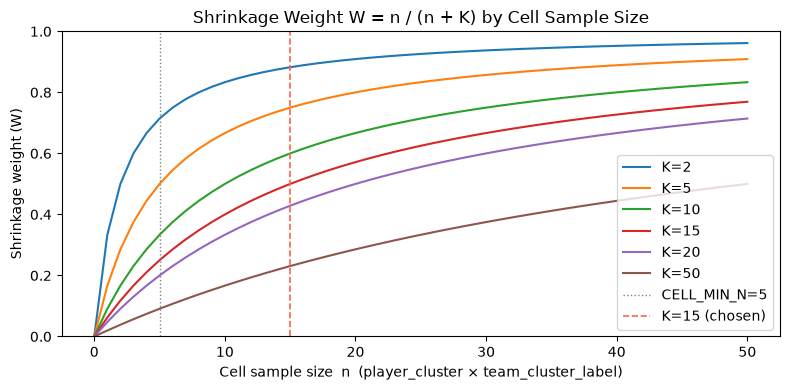

At K=15:
  n= 5 â†’ W=0.25  (cell contributes 25%, cluster prior contributes 75%)
  n=10 â†’ W=0.40  (cell contributes 40%, cluster prior contributes 60%)
  n=15 â†’ W=0.50  (cell contributes 50%, cluster prior contributes 50%)
  n=25 â†’ W=0.62  (cell contributes 62%, cluster prior contributes 38%)
  n=50 â†’ W=0.77  (cell contributes 77%, cluster prior contributes 23%)


In [11]:
# Cell 12 â€” Shrinkage sensitivity: W = n / (n + K) for different K values
K_values    = [2, 5, 10, 15, 20, 50]
n_obs_range = np.arange(0, 51)

fig, ax = plt.subplots(figsize=(8, 4))
for K in K_values:
    W = n_obs_range / (n_obs_range + K)
    ax.plot(n_obs_range, W, label=f"K={K}")

ax.axvline(CELL_MIN_N, color="gray", linestyle=":", linewidth=1,
           label=f"CELL_MIN_N={CELL_MIN_N}")
ax.axvline(SHRINKAGE_K, color="tomato", linestyle="--", linewidth=1.2,
           label=f"K={SHRINKAGE_K} (chosen)")
ax.set_title("Shrinkage Weight W = n / (n + K) by Cell Sample Size")
ax.set_xlabel("Cell sample size  n  (player_cluster Ã— team_cluster_label)")
ax.set_ylabel("Shrinkage weight (W)")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"At K={SHRINKAGE_K}:")
for n in [5, 10, 15, 25, 50]:
    W = n / (n + SHRINKAGE_K)
    print(f"  n={n:2d} â†’ W={W:.2f}  (cell contributes {W:.0%}, cluster prior contributes {1-W:.0%})")

## 7. Validation & Evaluation

Statistical evaluation of the pipeline's reliability. Rows with `has_prior_history=False`
(this dataset's earliest season, `success_probability` a constant 0.5 â€” see Section 4) are
excluded throughout: grading a coin flip and calling it a calibration result would just dilute
the genuine signal from every other season.


> **Production reference:** This section scores against `destination-backtest-v1` (Section 0).
> For the official baseline, run `uv run python scripts/run_transfer_success.py --phase backtest`
> on `player-destination-proj-v1` — that path logs Brier, ECE, `tier_calibration.csv`, and
> `calibration_curve.png` to MLflow experiment `transfer-success`.
| Section | What it measures |
|---|---|
| **7a. Success Probability Calibration** | Does `success_probability` actually predict success? Brier Score Loss + density split + tier success rates |

In [12]:
# Cell 13a â€” Validation setup: shared eval DataFrame
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

TIER_ORDER = ["Very Low", "Low", "Moderate", "High", "Very High"]

# Restrict to rows with a definitive labeled outcome AND a real (non-bootstrap)
# success_probability. has_prior_history=False means this row's season had ZERO prior-
# season training data (compute_success_probability's earliest-season fallback) â€” its
# success_probability is a constant 0.5, not a real estimate, and including it would
# just dilute genuine calibration/Brier results toward the uninformative baseline.
# Verified this isn't hypothetical: the season right after the dataset's first season
# gets EXACTLY 0.5 for every single row here (n=388, std=0.000) because that first
# season itself has zero success labels to train on â€” real, not a rounding artifact.
bootstrap_mask = ~result_df["has_prior_history"]
n_excluded = (bootstrap_mask & result_df["success_label"].notna()).sum()

eval_df = result_df[result_df["success_label"].notna() & result_df["has_prior_history"]].copy()
eval_df["success_int"] = eval_df["success_label"].astype(int)
eval_df["failed"]      = ~eval_df["success_label"].astype(bool)

print(f"Excluded {n_excluded:,} labeled rows with no prior-season training history "
      "(constant 0.5 bootstrap estimate, not a real prediction)")
print(f"Evaluation set: {len(eval_df):,} labeled transfers")
print(f"  Success: {eval_df['success_int'].sum():,}  |  Failure: {eval_df['failed'].sum():,}")
print(f"  Base rate: {eval_df['success_int'].mean():.1%} success  /  {eval_df['failed'].mean():.1%} failure")

Excluded 388 labeled rows with no prior-season training history (constant 0.5 bootstrap estimate, not a real prediction)
Evaluation set: 1,699 labeled transfers
  Success: 907  |  Failure: 792
  Base rate: 53.4% success  /  46.6% failure


In [13]:
# Cell 13b â€” 7a: Confidence calibration metrics (Brier Score + calibration curve)

# Empirical success rate and sample count per confidence tier
tier_stats = (
    eval_df
    .groupby("success_tier", observed=False)
    .agg(n=("success_int", "count"), actual_success_rate=("success_int", "mean"))
    .reindex(TIER_ORDER)
    .reset_index()
)

# Brier Score: mean squared error of predicted probability vs binary outcome
# Lower is better; 0.25 = coin-flip baseline at a 50/50 base rate
y_true = eval_df["success_int"]
y_prob  = eval_df["success_probability"]
brier   = brier_score_loss(y_true, y_prob)

# Calibration curve: fraction of positives vs mean predicted prob in quantile bins
frac_pos, mean_pred_prob = calibration_curve(y_true, y_prob, n_bins=5, strategy="quantile")

brier_interp = (
    "Excellent (<0.15)" if brier < 0.15
    else "Good (0.15â€“0.20)" if brier < 0.20
    else "Fair (0.20â€“0.25)" if brier < 0.25
    else "Weak â€” near coin-flip (â‰¥0.25)"
)

print(f"Brier Score Loss : {brier:.4f}   [{brier_interp}]")
print(f"Reference baseline : 0.25  (uninformative at 50/50 base rate)")

Brier Score Loss : 0.2239   [Fair (0.20â€“0.25)]
Reference baseline : 0.25  (uninformative at 50/50 base rate)


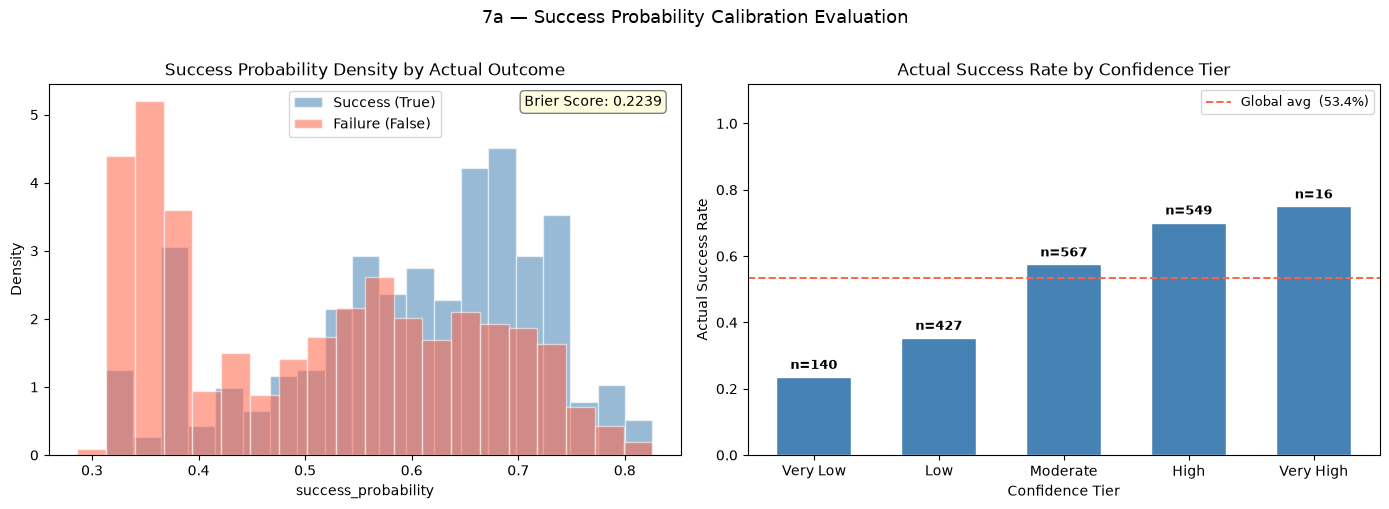

In [14]:
# Cell 13c â€” 7a: Calibration visualization (2-panel plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: success probability density split by actual outcome
for outcome, color, label in [
    (True,  "steelblue", "Success (True)"),
    (False, "tomato",    "Failure (False)"),
]:
    subset = eval_df.loc[eval_df["success_label"] == outcome, "success_probability"]
    axes[0].hist(subset, bins=20, alpha=0.55, density=True, color=color,
                 label=label, edgecolor="white")

axes[0].set_title("Success Probability Density by Actual Outcome", fontsize=12)
axes[0].set_xlabel("success_probability")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].text(
    0.97, 0.97,
    f"Brier Score: {brier:.4f}",
    transform=axes[0].transAxes, ha="right", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"),
)

# Right panel: actual success rate per confidence tier with "n=X" labels
valid_tiers = tier_stats[tier_stats["n"] > 0]
global_rate = eval_df["success_int"].mean()

bars = axes[1].bar(
    valid_tiers["success_tier"].astype(str),
    valid_tiers["actual_success_rate"],
    color="steelblue", edgecolor="white", width=0.6,
)
for bar, (_, row) in zip(bars, valid_tiers.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"n={int(row['n'])}",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )

axes[1].axhline(global_rate, color="tomato", linestyle="--", linewidth=1.4,
                label=f"Global avg  ({global_rate:.1%})")
axes[1].set_title("Actual Success Rate by Confidence Tier", fontsize=12)
axes[1].set_xlabel("Confidence Tier")
axes[1].set_ylabel("Actual Success Rate")
axes[1].set_ylim(0, 1.12)
axes[1].legend(fontsize=9)

plt.suptitle("7a â€” Success Probability Calibration Evaluation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Cell 13d â€” 7a: Calibration printout + tier summary table
print(f"\n{'â”€'*62}")
print(f"  Brier Score Loss    : {brier:.4f}   [{brier_interp}]")
print(f"  Reference baseline  : 0.25  (uninformative at 50/50 base rate)")
print(f"  Global success rate : {global_rate:.1%}  (n={len(eval_df):,} labeled transfers)")
print(f"\n  Calibration curve â€” quantile bins (mean predicted â†’ fraction positive):")
for mp, fp in zip(mean_pred_prob, frac_pos):
    gap = fp - mp
    direction = "over-confident" if gap < 0 else "under-confident"
    print(f"    predicted {mp:.3f}  â†’  actual {fp:.3f}   (gap {gap:+.3f}  {direction})")
print(f"{'â”€'*62}\n")

print("Tier Calibration Summary:")
display(
    tier_stats
    .assign(actual_success_rate=tier_stats["actual_success_rate"].map(
        lambda x: f"{x:.1%}" if pd.notna(x) else "â€”"
    ))
    .rename(columns={
        "success_tier":    "Confidence Tier",
        "n":                  "Count",
        "actual_success_rate":"Actual Success Rate",
    })
    .reset_index(drop=True)
)


â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  Brier Score Loss    : 0.2239   [Fair (0.20â€“0.25)]
  Reference baseline  : 0.25  (uninformative at 50/50 base rate)
  Global success rate : 53.4%  (n=1,699 labeled transfers)

  Calibration curve â€” quantile bins (mean predicted â†’ fraction positive):
    predicted 0.349  â†’  actual 0.275   (gap -0.075  over-confident)
    predicted 0.473  â†’  actual 0.461   (gap -0.012  over-confident)
    predicted 0.577  â†’  actual 0.588   (gap +0.010  under-confident)
    predicted 0.659  â†’  actual 0.675   (gap +0.016  under-confident)
    predicted 0.732  â†’  actual 0.692   (gap -0.040  over-confident)
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

Tier Calibratio

,Confidence Tier,Count,Actual Success Rate
0,Very Low,140,23.6%
1,Low,427,35.4%
2,Moderate,567,57.5%
3,High,549,70.1%
4,Very High,16,75.0%
